In [ ]:
from os import environ
from pathlib import Path
import sys

environ["OPENBLAS_NUM_THREADS"] = "1"
environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

_project_root = Path.cwd().resolve()
for _candidate in (_project_root, *_project_root.parents):
	if (_candidate / "crystal_funcs.py").exists():
		if str(_candidate) not in sys.path:
			sys.path.insert(0, str(_candidate))
		break
else:
	raise RuntimeError("Could not locate project root containing crystal_funcs.py")

import dataclasses as dcls
import matplotlib.pyplot as plt
import numpy as np
from sklearn.mixture import GaussianMixture

from matplotlib.path import Path
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import gaussian_kde
from scipy.spatial import Delaunay, ConvexHull
from scipy.interpolate import griddata
from scipy.special import factorial

# Local Imports
import src.crystal_funcs as cfuncs
from TriMap import TriMap
import symmetry as sym
from src.bases import CanonBasis2, CanonBasis3

ModuleNotFoundError: No module named 'crystal_funcs'

In [ ]:



_cmap = plt.get_cmap('afmhot').copy()
_cmap.set_bad(color='whitesmoke')

B = CanonBasis3()
B2 = CanonBasis2()

In [ ]:
def func2(*xi):
	x,y = xi
	return np.cos(2*np.pi*x**2) + np.sin(np.pi*y**2)


ndim = 2
_0 = np.zeros(ndim)
domain = np.array([(0, 1)]*ndim)
center = 0.5 * (domain[:,1] - domain[:,0])


N=99
xi = np.array([np.linspace(d[0], d[1], N, endpoint=False) for d in domain]) - center[:, None]
grid = np.meshgrid(*xi)
coords = np.vstack([x.ravel() for x in grid]).T + center

# Group operations
# Rotations & Identity
rot_order = 4
dθ = 2 * np.pi / rot_order
p4 = [(cfuncs.rot_mat(i * dθ), _0) for i in range(rot_order)]

# Glide Reflections
g =[
	(np.array([[-1, 0], [0,  1]]), center),
	(np.array([[1,  0], [0, -1]]), center),
	(np.array([[0,  1], [1,  0]]), center),
	(np.array([[0, -1], [-1, 0]]), center),
]

# Reflections
m = [
	(np.array([[1,  0], [0, -1]]), _0),
	(np.array([[-1, 0], [0,  1]]), _0),
	(np.array([[0,  1], [1,  0]]), _0),
	(np.array([[0, -1], [-1, 0]]), _0),
]

plot_names = ['original', 'p4gm', 'p4mm', 'p411']

# plot_func(func2,*grid,center=center, sym_ops=[[*p4, *g, *m], [*p4, *m], [*p4]])

fundamental_units = [
	0.5 * np.array([(1, 0), (1, 1), (0, 1)]),
	0.5 * np.array([(1, 0), (1, 1), (0, 1)]),
	0.5 * np.array([(1, 0), (1, 1), (0, 0)]),
	0.5 * np.array([(1, 0), (1, 1), (0, 1)]),
]

dirichlet_points = np.random.dirichlet([1.5,1.5,1.5], 50000)
dirichlet_weights = cfuncs.barycentric_weights(dirichlet_points)
n_samples=1000



In [ ]:
test_unit_verts = [(1, 0), (1, 1), (0, 1)]
test_polygon_verts = [(1.00, 0.00), (0.62, 0.78), (-0.22, 1), (-0.90, 0.2), (-0.90, -0.43), (-0.22, -0.97), (0.62, -0.78)]

test_unit = 0.5 * np.array(test_unit_verts)
test_unit_cent = cfuncs.centroid(test_unit)

polygon = np.array(test_polygon_verts)

n_samples = 5000

In [ ]:
f_sym = sym.symmetrize(func2, *grid, sym_ops=[*p4, *g, *m])
# distribution, distribution_weights = plot_weighted_distribution(f_sym, coords, test_unit, n_samples=n_samples, alpha=[1,1,1])
distribution, distribution_weights = cfuncs.weighted_distribution(f_sym, coords.T, test_unit, n_samples=n_samples)
# plot_weighted_dist(f_sym, coords.T, test_unit, n_samples=n_samples)

In [ ]:

def rot_mat(theta):
	row1 = np.stack([np.cos(theta), np.sin(theta)], axis=-1)    
	row2 = np.stack([-np.sin(theta), np.cos(theta)], axis=-1)
	return np.stack([row1, row2], axis=-1)

def prep_ply(ply):
	return cfuncs.scale_poly(ply.copy() - cfuncscentroid(ply))


def interp_vert2d(p:np.ndarray, src_vrts:np.ndarray, dst_vrts:np.ndarray):    
	v1, v2 = src_vrts[:, 0], src_vrts[:, 1]
	t1, t2 = dst_vrts[:, 0], dst_vrts[:, 1]
	if p.ndim == 1:
			t = np.linalg.norm(p - v1) / (np.linalg.norm(p - v2)+np.linalg.norm(p - v1))
			return t1 + t * (t2 - t1)
	elif p.ndim == 2:
			t = np.linalg.norm(p - v1, axis=1) / (np.linalg.norm(p - v2)+np.linalg.norm(p - v1))
			return t1 + t[:, None] * (t2 - t1)
	else:
			raise ValueError(f"Not supported for dimension {p.ndim}")

def interp_vert3d(p, src_vrts, dst_vrts):
    """
    """
    v1, v2, v3 = src_vrts[:, 0], src_vrts[:, 1], src_vrts[:, 2]
    t1, t2, t3 = dst_vrts[:, 0], dst_vrts[:, 1], dst_vrts[:, 2]
    dist_p_v1 = np.linalg.norm(p - v1, axis=1, keepdims=True)
    dist_p_v2 = np.linalg.norm(p - v2, axis=1, keepdims=True)
    dist_p_v3 = np.linalg.norm(p - v3, axis=1, keepdims=True)
    param1 = (dist_p_v1 / (dist_p_v1 + dist_p_v2))
    param2 = (dist_p_v2 / (dist_p_v2 + dist_p_v3))
    return ((t1 + param1 * (t2 - t1)) + (t2 + param2 * (t3 - t2))) / 2


def collect_matrices2d(src_poly:np.ndarray, dst_poly:np.ndarray, num_rots=12):
    """
    """
    npts_dst, ndim = dst_poly.shape
    npts_src, ndim = src_poly.shape
    if ndim == 2:
        interp_func = interp_vert2d
    elif ndim == 3:
        interp_func = interp_vert3d
    else:
        raise ValueError(f"Not supported for dimension {ndim}")
    
    src_ply = prep_ply(src_poly)
    dst_ply = prep_ply(dst_poly)

    thetas = np.linspace(0, 2 * np.pi, num_rots, endpoint=False)
    mats = rot_mat(thetas)
    rotated_plys = dst_ply @ mats
    combos = unique_tuples(dst_ply.shape[0], ndim+1)
    cents = np.zeros((num_rots, 1, ndim))
    rotated_plys_w_cent = np.hstack([rotated_plys, cents])
    dst_w_cent = np.array(list(dst_ply) + [np.zeros(ndim)])

    piecewise_matrices, dst, triangulations, src, simps = [], [], [], [], []
    for combo in combos:
        # Shape (num_rots, ndim+1, ndim)
        rotated_simps = rotated_plys[:, combo, :]
        mask = np.ones(npts_dst, dtype=bool)
        mask[combo] = False

        # Shape (num_rots, npts_dst - (ndim+1), ndim)
        others = rotated_plys[:, mask, :]


        dst_pts = np.zeros_like(rotated_plys)
        # Mapping the chosen coordinates to the simplex
        dst_pts[:, combo, :] = src_ply

        # Shape (num_rots, npts_dst - (ndim+1), ndim+1)
        bary_others = np.array([calculate_barycentric_coordinates(src_ply, rot) for rot in others])
        # largest ndim barycentric coords, corresponding to closest face/side
        # for each rotation, for each remaining point, the nearest boundary side
        # Shape (num_rots, npts_dst - (ndim+1), ndim)
        closest_face = np.argsort(bary_others, axis=-1)[:,:, -ndim:]
        
        # Shape (num_rots, 1, 1)
        rows = np.arange(num_rots)[:, None, None]

        src_faces = src_ply[closest_face]
        # for each rotation, for each remaining point, the nearest boundary side coordinates
        dst_faces = rotated_simps[rows, closest_face]
        
        # Shape src_face = (npts_dst - (ndim+1), ndim, ndim)
        interped_pts = np.array([
            interp_func(other_pts, 
                        src_face[:, :ndim], 
                        dst_face[:, :ndim]) 
                        for other_pts, src_face, dst_face in zip(others, src_faces, dst_faces)
                                 ])
        
        dst_pts[:, mask, :] = interped_pts
        dst_pts_w_cent = np.hstack([dst_pts, cents])
        tri_dst = [Delaunay(ply) for ply in dst_pts_w_cent]
        simplices = [tri.simplices for tri in tri_dst]
        triangulations.extend(tri_dst)
        simps.extend(simplices)
        dst.extend(list(dst_pts_w_cent.copy()))
        src.extend(list(rotated_plys_w_cent.copy()))

        piecewise_matrices.extend([
            piecewise_tforms(src_pt, dst_pt, tri) 
            for src_pt, dst_pt, tri in zip(rotated_plys_w_cent, dst_pts_w_cent, simplices)
            ])
        
    return piecewise_matrices, triangulations, simps, dst, src

def nsimplex_volume(vertices:np.ndarray):
    """
    Parameters
    ----------------
    vertices:np.ndarray
    """
    edge_vectors = vertices[..., 1:, :] - vertices[..., 0, np.newaxis, :]
    det = np.linalg.det(edge_vectors)
    n = vertices.shape[-1]
    return np.abs(det) / factorial(n)

def dirichlet_energy(matrices, mapping, triangulation, poly):
    """
    Parameters
    ----------------
    matrices:np.ndarray, 
    
    mapping:np.ndarray,
    
    triangulation:np.ndarray
    
    polyhedron
    
    """
    # TODO dont need to calculate volumes every time (in class)
    volumesA = nsimplex_volume(poly[triangulation])
    volumesB = nsimplex_volume(mapping[triangulation])

    # Singularities
    if np.any(volumesA == 0) or np.any(volumesB==0):
            return np.inf
    try:
        svs = np.array([np.linalg.svd(J, compute_uv=False) for J in matrices])
        inv_svs = np.array([np.linalg.svd(np.linalg.inv(J), compute_uv=False) for J in matrices])
        spectral_norms = np.max(svs, axis=1)**2 * volumesB + np.max(inv_svs, axis=1)**2 * volumesA
        return np.sum(spectral_norms)
    except:
        print("singular matrices")
        return np.inf
    
def minimize_jacobian(matrices, maps, triangulations, rotated_plys):
    """
    Parameters
    ----------------
    matrices, 
    
    maps, 
    
    triangulations, 
    
    rotated_plys
        
    """
    energies = np.array([dirichlet_energy(mats, maps, tris, polys) 
                            for mats, maps, tris, polys in zip(matrices, maps, triangulations, rotated_plys)])
    print("Minimal energy value:", energies[np.argmin(energies)])
    return np.argmin(energies)

def unique_tuples(num_pts, tuple_len):
    """
    Parameters
    ----------------
    num_pts, tuple_len
    """
    indices = np.arange(0, num_pts)
    combinations = np.array(np.meshgrid(*[indices for _ in range(tuple_len)])).T.reshape(-1, tuple_len)
    combinations.sort(axis=1)
    unique_mask = np.all(np.diff(combinations, axis=1) != 0, axis=1)
    return np.unique(combinations[unique_mask], axis=0)

In [39]:

# fig = plt.figure(figsize=(12,12))
    # axes = [fig.add_subplot(1, num_rots, i+1) for i in range(num_rots)]    
    # for i, ax in enumerate(axes):
    #     plot_polygon(rotated_plys[i], ax)

class TriMap:
    """
    """
    def __init__(self, polygon:np.ndarray, triangle:np.ndarray) -> None:
        """
        polygon : array of vertices of polygon
        """
        self.polygon = polygon
        self.npts, self.dim = polygon.shape
        self.triangle = triangle
        self._setup_shapes()

        if self.dim == 2:
            self.interp_func = interp_vert2d
        elif self.dim == 3:
            self.interp_func = interp_vert3d
        else:
            raise ValueError(f"Not supported for dimension {self.dim}")
        
    def _setup_shapes(self) -> None:
        """
        """
        self.polygon = self.polygon - centroid(self.polygon.copy())
        self.triangle = self.triangle - centroid(self.triangle.copy())
        self.combos = unique_tuples(self.npts, self.dim+1)

    def define_distribution(self, 
                            distribution: np.ndarray = None, 
                            distribution_weights: np.ndarray = None, 
                            alpha=[1,1,1], 
                            nsamples=10000) -> None:
        """

        Parameters
        ----------------
        distribution : np.ndarray, default: None

        distribution_weights : np.ndarray, default: None

        alpha : list, default: = [1,1,1]

        nsamples : int, default: 10000
        """
        if distribution is None:
            dirichlet_points = np.random.dirichlet(alpha, nsamples)
            # points = np.dot(dirichlet_points, self.triangle)
            points = bary_to_cart(dirichlet_points, self.triangle)
            self.distribution_weights = barycentric_weights(dirichlet_points)
            self.distribution = points[self.distribution_weights > 0]
        else:
            if distribution.shape[-1] != self.dim + 1:
                print(distribution.shape)
                raise ValueError("No")
            self.distribution = distribution
            self.distribution_weights = distribution_weights

    def create_mapping(self, num_rots=12):
        """
        """
        maps, matrices, rotated_polygons, triangulations, simps = [], [], [], [], []

        dst_ply = self.polygon.copy()
        rot_poly = self.polygon.copy()
        

        thetas = np.linspace(0, 2 * np.pi, num_rots, endpoint=False)
        mats = rot_mat(thetas)
        rotated_plys = dst_ply @ mats
        cents = np.zeros((num_rots, 1, self.dim))
        rotated_plys_w_cent = np.hstack([rotated_plys, cents])

        triangle = self.triangle.copy()
        src_ply = self.triangle.copy()
        # for i in range(3):
        #     # To interate over which vertices are mapped to which triangle vertices - better explanation
        #     triangle = np.roll(self.triangle.copy(), i, axis=0)
        for combo in self.combos:
            # For the given combo, these are the rotated points that will map to the vertices of the simplex
            rotated_simps = rotated_plys[:, combo, :]
            dst_pts = np.zeros_like(rotated_plys)
            dst_pts[:, combo, :] = src_ply

            mask = np.ones(self.npts, dtype=bool)
            mask[combo] = False
            # Shape (num_rots, npts_dst - (ndim+1), ndim)
            others = rotated_plys[:, mask, :]
            
            # bary_others = np.array([calculate_barycentric_coordinates(src_ply, rot) for rot in others])
            # bary coords of other pts w.r.t. the simplex
            bary_others = np.array([calculate_barycentric_coordinates(src_ply, rot) for rot in others])
            closest_face = np.argsort(bary_others, axis=-1)[:,:, -self.dim:]
            
            rows = np.arange(num_rots)[:, None, None]
            
            src_faces = src_ply[closest_face]
            # for each rotation, for each remaining point, the nearest boundary side coordinates
            dst_faces = rotated_simps[rows, closest_face]

            interped_pts = np.array([
                self.interp_func(other_pts, dst_face[:, :self.dim], src_face[:, :self.dim]) 
                        for other_pts, src_face, dst_face in zip(others, src_faces, dst_faces)
                                 ])

            dst_pts[:, mask, :] = interped_pts
            dst_pts_w_cent = np.hstack([dst_pts, cents])

            tri_dst = [Delaunay(ply) for ply in dst_pts_w_cent]
            simplices = [tri.simplices for tri in tri_dst]
            triangulations.extend(tri_dst)
            
            simps.extend(simplices)
            maps.extend(list(dst_pts_w_cent.copy()))
            rotated_polygons.extend(list(rotated_plys_w_cent.copy()))

            matrices.extend([
                piecewise_tforms(src_pt, dst_pt, tri) 
                for src_pt, dst_pt, tri in zip(rotated_plys_w_cent, dst_pts_w_cent, simplices)
                ])

        # for combo in self.combos:
        #     rot_poly = self.polygon.copy()
        #     for ply in rotated_plys:
        #     # for mat in mats:
        #         # for i in range(3):
        #         #     triangle = np.roll(self.triangle.copy(), i, axis=0)
        #         # dst_pts = self.polygon.copy()
        #         dst_pts = np.zeros_like(rot_poly)
        #         dst_pts = self.map_polygon_to_triangle(triangle, combo, dst_pts)

        #         # polygon_wc = np.array(list(self.polygon) + [np.zeros(2)])
        #         polygon_wc = np.array(list(rot_poly) + [np.zeros(2)])
        #         dst_wc = np.array(list(dst_pts) + [np.zeros(2)])
        #         piecewise_matrices, triangulation = self._triangulation_method(polygon_wc, dst_wc)
        #         matrices.append(piecewise_matrices)
        #         triangulations.append(triangulation)
        #         maps.append(dst_wc)
        #         rotated_polygons.append(polygon_wc.copy())
        #         rot_poly = ply
        #         # rot_poly = self.polygon.copy() @ mat
        #     # rot_poly = self.polygon.copy() @ mat
        #     # self.polygon = self.polygon @ rot_mat(2*np.pi/num_rots)

        # print([len(m) for m in maps])
        self.maps = np.asarray(maps)
        # print([M.shape for M in matrices])
        self.matrices = matrices
        # self.matrices = np.asarray(matrices)
        self.triangulations = np.asarray(triangulations)
        self.rotated_polygons = np.asarray(rotated_polygons)
        return self.maps, self.matrices, self.triangulations, self.rotated_polygons

    def map_polygon_to_triangle(self, triangle:np.ndarray, tri_indices:np.ndarray, dst_pts:np.ndarray):
        """
        """
        dst_pts[tri_indices] = triangle
        
        # TODO vectorize 
        # if is_self_intersecting(dst_pts): 
        #     return None
        
        last_index = -1
        v1_idx, v2_idx = tri_indices[last_index%3], tri_indices[(last_index+1)%3]
        src_v1, src_v2 = self.polygon[v1_idx], self.polygon[v2_idx]
        dst_v1, dst_v2 = dst_pts[v1_idx], dst_pts[v2_idx]
        for j, p in enumerate(self.polygon):
            # TODO vectorize

            if j in tri_indices:
                # continue
                last_index += 1
                v1_idx, v2_idx = tri_indices[last_index%3], tri_indices[(last_index+1)%3]
                src_v1, src_v2 = self.polygon[v1_idx], self.polygon[v2_idx]
                dst_v1, dst_v2 = dst_pts[v1_idx], dst_pts[v2_idx]
            else:
                src_side = np.array([src_v1, src_v2]).T
                dst_side = np.array([dst_v1, dst_v2]).T
                dst_pts[j] = self.interp_func(p, src_side, dst_side)
        return dst_pts

    def _triangulation_method(self, src_pts, dst_pts):
        tri_poly_dst = Delaunay(dst_pts)
        piecewise_matrices = piecewise_tforms(src_pts, dst_pts, tri_poly_dst.simplices)
        return piecewise_matrices, tri_poly_dst

    def dirichlet_energy(self, matrices:np.ndarray, mapping:np.ndarray, triangulation:Delaunay, polygon):
        areasA = unsigned_area(polygon[triangulation.simplices])
        areasB = unsigned_area(mapping[triangulation.simplices])
        spectral_norms = np.array([max(np.linalg.svd(J)[1])**2 * B + max(np.linalg.svd(np.linalg.inv(J))[1])**2 * A for J, A, B in zip(matrices, areasA, areasB)])
        return np.sum(spectral_norms)

    def minimize_jacobian(self):
        energies = np.array([self.dirichlet_energy(mats, maps, tris, polys) 
                             for mats, maps, tris, polys in zip(self.matrices, self.maps, self.triangulations, self.rotated_polygons)])
        optimal_index = np.argmin(energies)
        print(energies[optimal_index])
        return optimal_index

224.4805462012562
Minimal energy value: 224.48054620125623
121


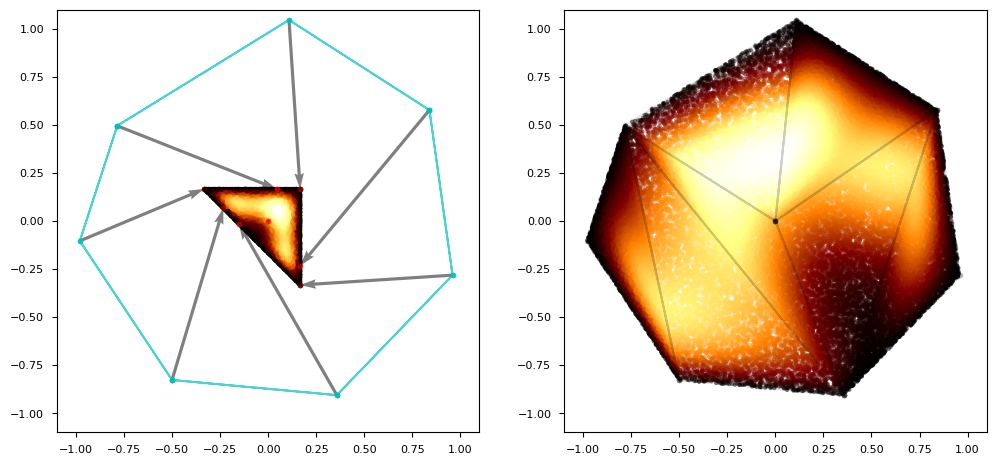

In [ ]:
test_unit = np.array([(0.5,0),(0.5,0.5),(0,0.5)])
test_unit_cent = centroid(test_unit)
polygon = np.array([(1.00, 0.00), (0.62, 0.78), (-0.22, 1), (-0.90, 0.2), (-0.90, -0.43), (-0.22, -0.97), (0.62, -0.78)])
n_samples=50000
f_sym = sym.symmetrize(func2, *grid, sym_ops=[*p4, *g, *m])
# distribution, distribution_weights = plot_weighted_distribution(f_sym, coords, test_unit, n_samples=n_samples, alpha=[1,1,1])
# plot_weighted_dist(f_sym, coords.T, test_unit, n_samples=n_samples)

distribution, distribution_weights = weighted_distribution(f_sym, coords.T, test_unit, n_samples=n_samples)

dir_points = calculate_barycentric_coordinates(test_unit, distribution)
dir_weights = barycentric_weights(dir_points)

centered_dist = distribution - test_unit_cent

total_weights = distribution_weights * dir_weights

num_rots = 20

map = TriMap(polygon, test_unit)
define_distribution(map.triangle, map.dim, distribution=barycentric_coordinates2D(centered_dist, test_unit), distribution_weights=total_weights)
out = map.create_mapping(num_rots)
idx = map.minimize_jacobian()
triangulations = [tri.simplices for tri in map.triangulations]
idx = minimize_jacobian(map.matrices, map.maps, triangulations, map.rotated_polygons)
print(idx)
best_map = map.maps[idx]
best_mats = map.matrices[idx]
best_poly = map.rotated_polygons[idx]
best_tri = map.triangulations[idx]
dist = bary_to_cart(dir_points, map.triangle)

# print(best_map, best_mats, best_poly, best_tri)
plot_result(best_map, best_mats, best_poly, best_tri, centered_dist, total_weights)

In [95]:

def calculate_barycentric_coordinates(vertices: np.ndarray, points: np.ndarray):
    """
    Parameters
    ----------------
    vertices

    points
    """
    # A = np.vstack([vertices.T, np.ones(vertices.shape[0])])
    # b = np.hstack([points, np.ones((points.shape[0],1))]).T
    A = np.vstack([np.ones(vertices.shape[0]), vertices.T])
    b = np.hstack([np.ones((points.shape[0], 1)), points]).T
    barycentric_coords, r, _, _ = np.linalg.lstsq(A, b, rcond=-1)
    if np.any(r):
        print(f"barycentric residual: {r}")
    return barycentric_coords.T

def barycentric_coordinates2D(p, triangle):    
    """
    Parameters
    ----------------
    p
    
    a
    
    b
    
    c
    """
    a,b,c = triangle[0], triangle[1], triangle[2]
    v0 = b - a
    v1 = c - a
    v2 = p - a
    d00 = np.dot(v0, v0)
    d01 = np.dot(v0, v1)
    d11 = np.dot(v1, v1)
    d20 = np.dot(v2, v0.T)
    d21 = np.dot(v2, v1.T)
    denom = d00 * d11 - d01 * d01
    l1 = (d11 * d20 - d01 * d21) / denom
    l2 = (d00 * d21 - d01 * d20) / denom
    l3 = 1-l1-l2
    return np.vstack([l3, l1, l2]).T

In [34]:
test = barycentric_coordinates2D(test_unit, test_unit)
print(test)
print(bary_to_cart(test, test_unit))
print(test_unit)

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
[[0.5 0. ]
 [0.5 0.5]
 [0.  0.5]]
[[0.5 0. ]
 [0.5 0.5]
 [0.  0.5]]


In [21]:
dist2d, dist_weights2d = weighted_distribution(f_sym, coords.T, test_unit, n_samples=n_samples)
dir_points = calculate_barycentric_coordinates(test_unit, dist2d)
dir_weights = barycentric_weights(dir_points)


total_weights = dist_weights2d * dir_weights
centered_dist = dist2d #- test_unit_cent
bary_coords = barycentric_coordinates2D(centered_dist, test_unit)


bary_coords2 = calculate_barycentric_coordinates(test_unit, centered_dist)
print(bary_coords-bary_coords2)

[[-8.32667268e-17  3.33066907e-16 -3.33066907e-16]
 [ 2.22044605e-16  5.55111512e-17 -2.22044605e-16]
 [ 1.11022302e-16  1.94289029e-16 -4.44089210e-16]
 [ 3.46944695e-17  0.00000000e+00 -2.49800181e-16]
 [ 1.11022302e-16 -1.11022302e-16 -2.63677968e-16]
 [ 3.33066907e-16  0.00000000e+00 -1.11022302e-16]
 [ 1.80411242e-16  2.22044605e-16 -1.66533454e-16]
 [ 3.33066907e-16 -9.71445147e-17 -1.66533454e-16]
 [ 5.55111512e-16 -3.01841885e-16 -1.11022302e-16]
 [ 3.19189120e-16  0.00000000e+00 -1.66533454e-16]
 [-7.63278329e-17 -2.77555756e-17  0.00000000e+00]
 [ 0.00000000e+00 -8.32667268e-17 -3.05311332e-16]
 [ 6.66133815e-16 -1.17961196e-16 -8.32667268e-17]
 [ 5.55111512e-16 -8.32667268e-17 -2.82759927e-16]
 [ 4.44089210e-16 -5.55111512e-17 -2.77555756e-17]
 [ 2.77555756e-16  8.32667268e-17 -1.66533454e-16]
 [ 1.66533454e-16  1.66533454e-16  5.55111512e-17]
 [ 1.94289029e-16  5.55111512e-17 -5.55111512e-17]
 [ 2.77555756e-16  1.66533454e-16 -5.55111512e-17]
 [-2.77555756e-17  2.22044605e-

In [19]:
bary_coords = barycentric_coordinates2D(centered_dist, test_unit)


bary_coords2 = calculate_barycentric_coordinates(test_unit, centered_dist)
print(bary_coords-bary_coords2)

[[ 0.30155752  0.13077483 -0.43233235]
 [-0.01862257  0.36437867 -0.34575611]
 [-0.59242686  0.2485191   0.34390776]
 [ 0.04492865  0.84955177 -0.89448042]
 [-0.30000876  0.43285542 -0.13284666]
 [ 0.27658469 -0.09477567 -0.18180903]
 [-0.15869396  0.27164935 -0.11295539]
 [-0.29831806  0.14159977  0.15671829]
 [-0.4563339  -0.20862232  0.66495622]
 [-0.50479449 -0.23387287  0.73866737]
 [ 0.70553229 -0.4691905  -0.23634179]
 [ 0.41690609 -0.40695462 -0.00995147]
 [-0.17293987 -0.37631962  0.54925949]
 [-0.50262706 -0.01093847  0.51356553]
 [-0.3942159   0.17781331  0.2164026 ]
 [ 0.30045955 -0.50978303  0.20932348]
 [-0.11291639  0.43437966 -0.32146328]
 [ 0.41127693 -0.33130837 -0.07996856]
 [-0.67596674 -0.16195683  0.83792356]
 [ 0.74059443 -0.75913676  0.01854233]
 [-0.02827947  0.42459091 -0.39631144]
 [ 0.53302624 -0.38698306 -0.14604318]
 [ 0.41671546 -0.33088163 -0.08583383]
 [ 0.26221645 -0.33968846  0.07747201]
 [ 0.75504445 -0.85047846  0.09543401]
 [-0.24825079  0.67404998